<a href="https://colab.research.google.com/github/NaujQD/cardiovascular-disease-ml/blob/main/cardiovascular_risk_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hello World: cardiovascular-risk-ml-QD
## Machine learning project for cardiovascular disease prediction using public available data Cardiovascular Disease Prediction (ML Project) Overview

This project explores the use of machine learning models to predict cardiovascular disease using clinical data.

The goal is to evaluate how well these models perform and assess their potential applicability in real clinical environments.

### Dataset

Public dataset: Cleveland Heart Disease Dataset

~300 patients

14 clinical variables (age, cholesterol, blood pressure, etc.)

### Tools & Technologies

Python

pandas

scikit-learn

matplotlib

### Methodology

Data cleaning and preprocessing

Feature scaling (StandardScaler)

Train-test split (80/20)

Logistic Regression model

### Model evaluation using:

Accuracy

Precision / Recall

F1-score

Confusion Matrix

# 1. We load the necessary libraries and then proceed to Drive to upload the .csv file containing the data

Project Setup and Data Loading:

We started by importing necessary libraries (numpy, pandas, seaborn, matplotlib).
We mounted Google Drive to access our dataset.
We loaded the heart.csv dataset into a pandas DataFrame named df.
We displayed the first few rows (df.head()), descriptive statistics (df.describe()), and data types (df.dtypes) to get an initial understanding of the data.

In [63]:
# We load the neccessary requierements
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
# Load the corresponding dataset into our notebook. I'm using google drive.
df = pd.read_csv('/content/drive/MyDrive/QD/heart.csv')


print(df.head())
print(df.describe())
print("data type of each collum:")
print(df.dtypes)
print()



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   age  sex  chest_pain  blood_pressure  cholesterol  fasting_glucose  \
0   63    1           1             145          233                1   
1   67    1           4             160          286                0   
2   67    1           4             120          229                0   
3   37    1           3             130          250                0   
4   41    0           2             130          204                0   

   restecg  max_heart_rate  exang  oldpeak  slope  ca  thal  diagnosis  
0        2             150      0      2.3      3   0     6          0  
1        2             108      1      1.5      2   3     3          2  
2        2             129      1      2.6      2   2     7          1  
3        0             187      0      3.5      3   0     3          0  
4        2             172      0      1.4      1   0     3        

## Let's check for missing values by variable


Number of missing values per variable:
 age                0
sex                0
chest_pain         0
blood_pressure     0
cholesterol        0
fasting_glucose    0
restecg            0
max_heart_rate     0
exang              0
oldpeak            0
slope              0
ca                 0
thal               0
diagnosis          0
dtype: int64


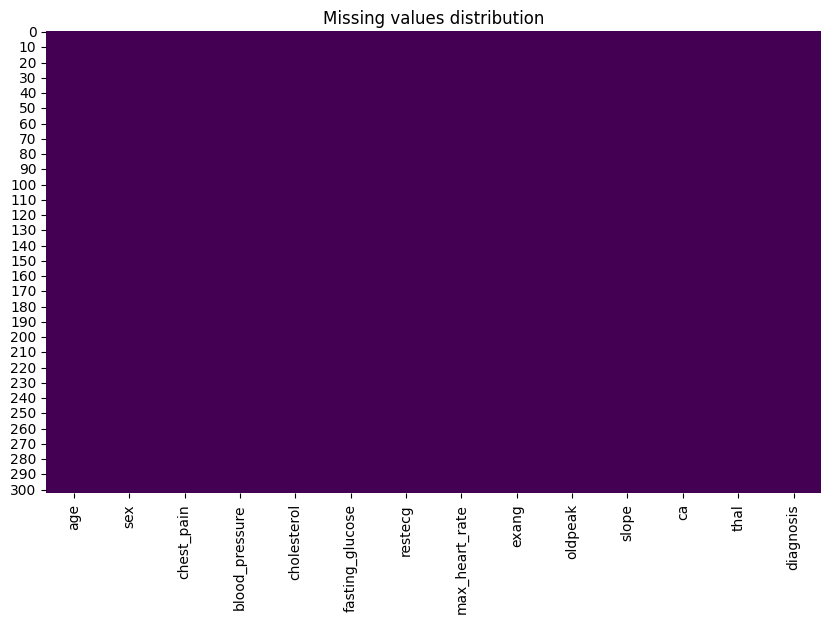

In [64]:
# We need to look for missing values
missing_values = df.isnull().sum()
print("Number of missing values per variable:\n", missing_values)
# Also we can view the correlation between missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing values distribution")
plt.show()

## We verify that the target variable—in this case, “diagnosis”—is properly classified and that the sample size is appropriate

Target Variable Preparation:

We examined the distribution of the original diagnosis column and observed it had 5 unique values (0, 1, 2, 3, 4).
We transformed the diagnosis column into a binary target variable y, where 0 indicates no heart disease and 1 indicates the presence of heart disease (by mapping original values > 0 to 1).
We separated features (X) from the target variable (y).


In [65]:
print(df['diagnosis'].value_counts())
y = (df['diagnosis'] > 0).astype(int)
X = df.drop('diagnosis', axis=1)
print(y.value_counts())

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

diagnosis
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64
diagnosis
0    164
1    139
Name: count, dtype: int64
Shape of X: (303, 13)
Shape of y: (303,)


## Let's create a graph to visualize the correlation matrix
## Generate a heat map of the correlation matrix

Correlation Analysis:

We generated and visualized a correlation matrix for all features, including the original diagnosis column, using a heatmap. This helped us understand the linear relationships between variables.
We specifically analyzed the correlation of each feature with diagnosis after creating df_scaled_with_diagnosis.
We discussed the difference between correlation and causation, particularly in the context of max_heart_rate and its negative correlation with diagnosis.

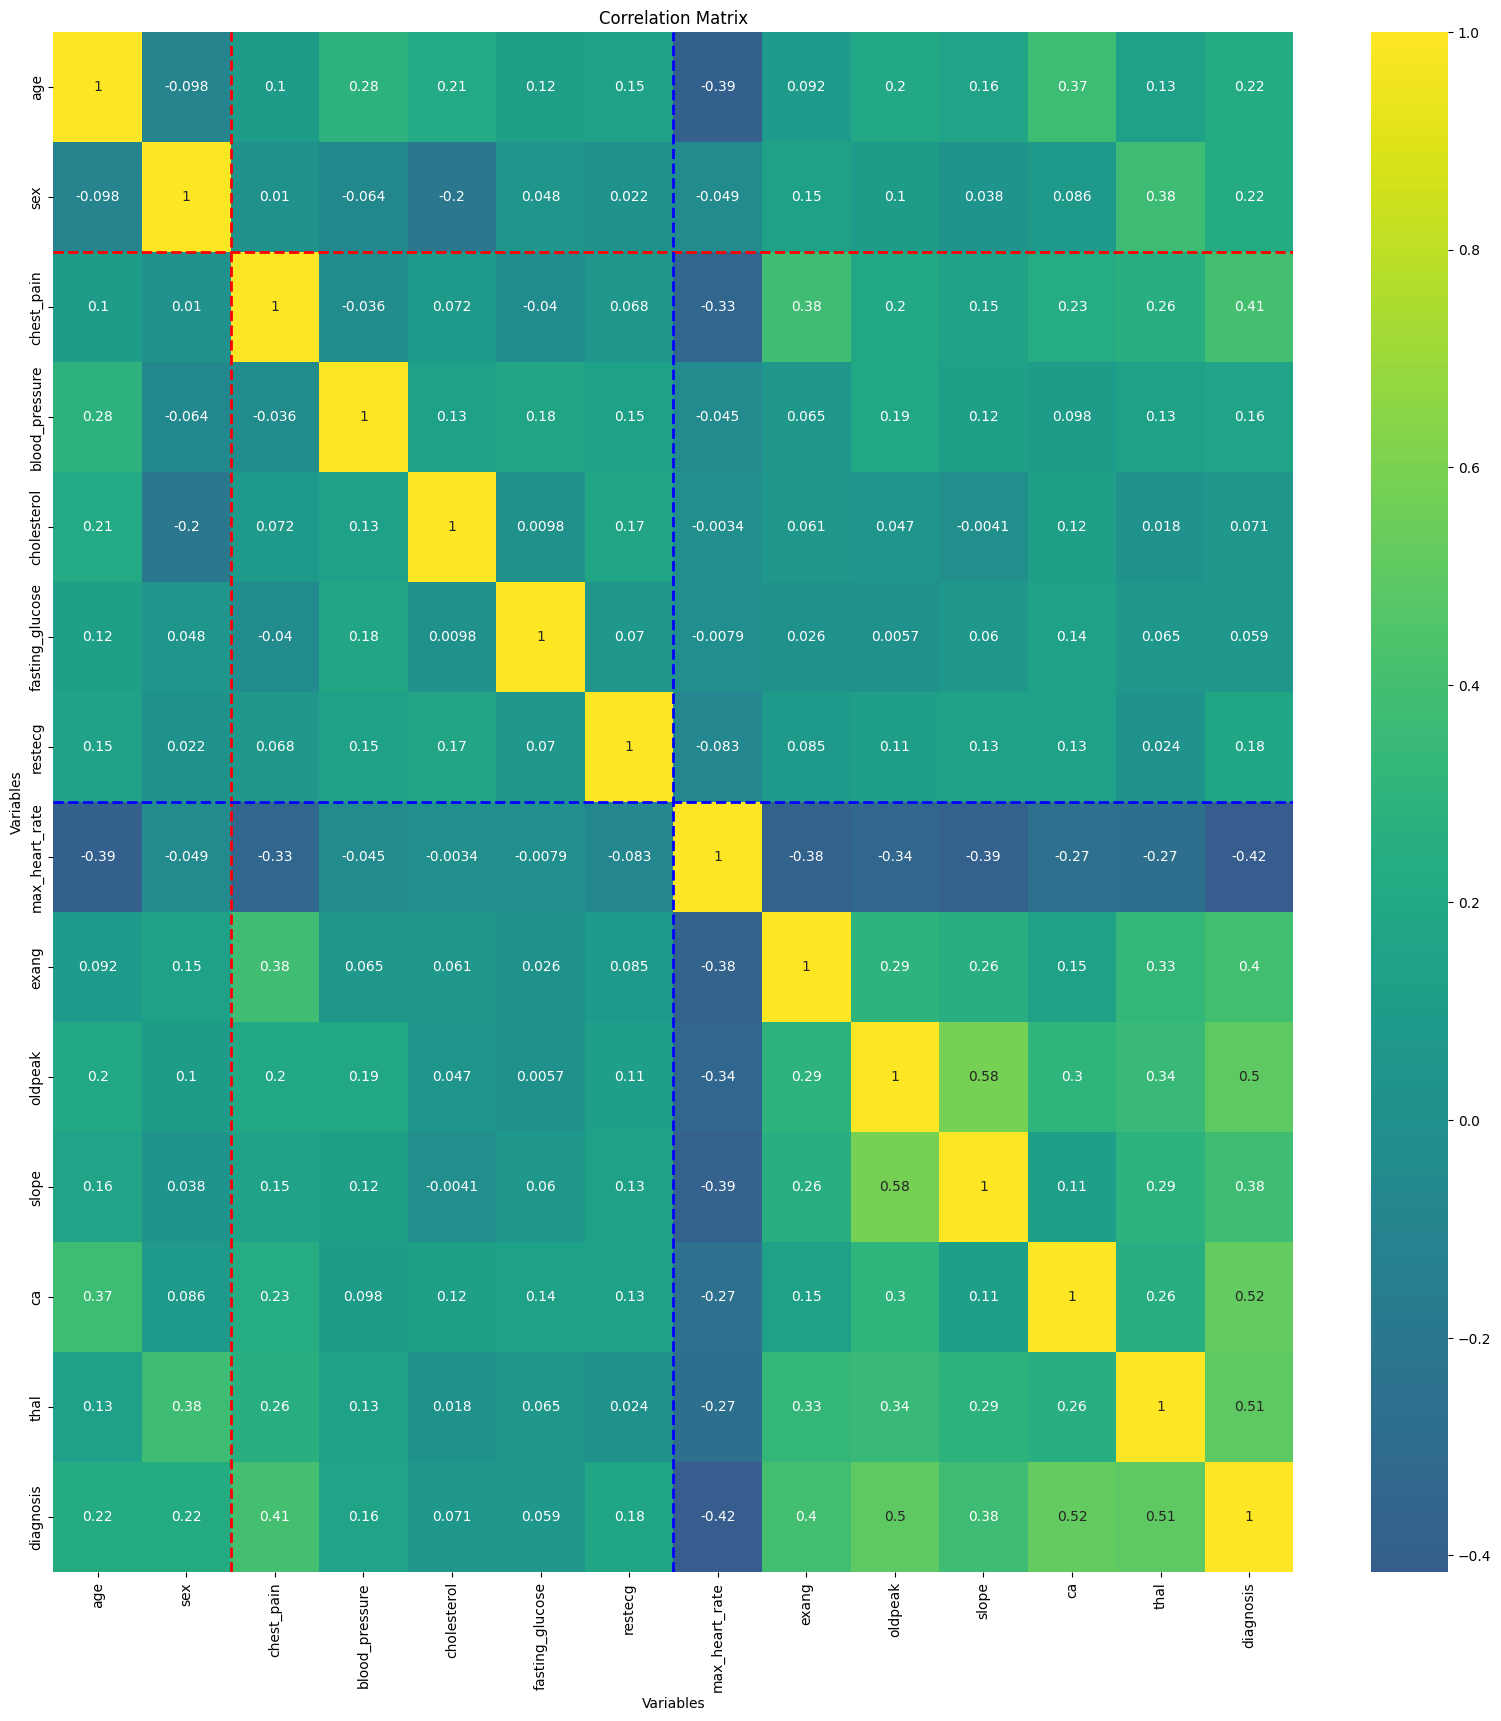

In [66]:
# Create a figure to visualize the correlation matrix
plt.figure(figsize=(20, 20))
# Generate a heatmap of the correlation matrix
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', center=0)
# Add lines to separate different types of variables
plt.axvline(x=2, color='r', linestyle='--', linewidth=2)  # Vertical line to separate categorical variables
plt.axhline(y=2, color='r', linestyle='--', linewidth=2)  # Horizontal line to separate categorical variables
plt.axvline(x=7, color='b', linestyle='--', linewidth=2)  # Vertical line to separate continuous variables
plt.axhline(y=7, color='b', linestyle='--', linewidth=2)  # Horizontal line to separate continuous variables
# Configure titles and axis labels
plt.title('Correlation Matrix')
plt.xlabel('Variables')
plt.ylabel('Variables')
plt.show()


### Exploring Features with Low Correlation to Diagnosis

Initial Feature Visualization (Box Plots & Scatter Plot):

We created box plots to visualize the relationship of fasting_glucose, restecg, blood_pressure, and cholesterol with the binary diagnosis.
We generated a scatter plot to explore the relationship between cholesterol and max_heart_rate, with points colored by diagnosis.
We further visualized the relationship of 'ca' (number of major vessels) and 'thal' (thallium stress test result) with 'diagnosis' using box plots, confirming their strong association.

#### Explain the difference between correlation and causation for these features

A very important distinction in data analysis! Here's a breakdown of the difference between correlation and causation, specifically for the features in our dataset:

Correlation: Correlation measures the statistical relationship between two variables. When two variables are correlated, it means that they tend to change together. For example, if we say age is positively correlated with diagnosis, it means that as a person's age increases, the likelihood of a heart disease diagnosis also tends to increase. However, this doesn't mean that increasing age causes heart disease.

In our correlation analysis, we've identified features like ca, thal, oldpeak, chest_pain, and max_heart_rate.1 (likely exercise-induced angina) as having the strongest correlations with diagnosis. This means these features are strong indicators or predictors of the diagnosis.

Causation: Causation, on the other hand, means that one event or variable directly causes another event or variable to happen. Establishing causation is much more difficult than establishing correlation and usually requires carefully designed experiments or in-depth domain knowledge.

For instance, while smoking is highly correlated with lung cancer, scientific studies have established that smoking actually causes lung cancer. In our heart disease dataset, a correlation between cholesterol and diagnosis suggests that high cholesterol is associated with heart disease, but without further medical and experimental evidence, we cannot definitively say that high cholesterol causes heart disease (though medical science does strongly support a causal link).

# Key Takeaway for our model:

Our machine learning model is designed to find and use these correlations to predict heart disease. Even if a feature doesn't cause heart disease, if it's strongly correlated, it can still be a valuable predictor for the model. For example, blood_pressure is correlated, and while high blood pressure contributes to heart disease, the model primarily uses the statistical relationship to make predictions. Causation is crucial for understanding the underlying biological mechanisms and for developing interventions, but for a predictive model, strong correlations are often sufficient.


# Explain the max_heart_rate variable and its negative correlation The max_heart_rate variable represents the maximum heart rate achieved by the individual during an exercise test.

This is often an indicator of cardiovascular fitness.

Regarding its negative correlation with the diagnosis (where 0 indicates no disease and 1 indicates disease), it means that as the maximum heart rate achieved by a person increases, their likelihood of having a heart disease diagnosis tends to decrease.

In simpler terms: individuals who can reach a higher maximum heart rate during exercise are generally considered to have better cardiovascular health, and therefore are less likely to be diagnosed with heart disease. Conversely, those with lower maximum heart rates might have underlying heart conditions that limit their ability to exert themselves, leading to a higher chance of diagnosis.

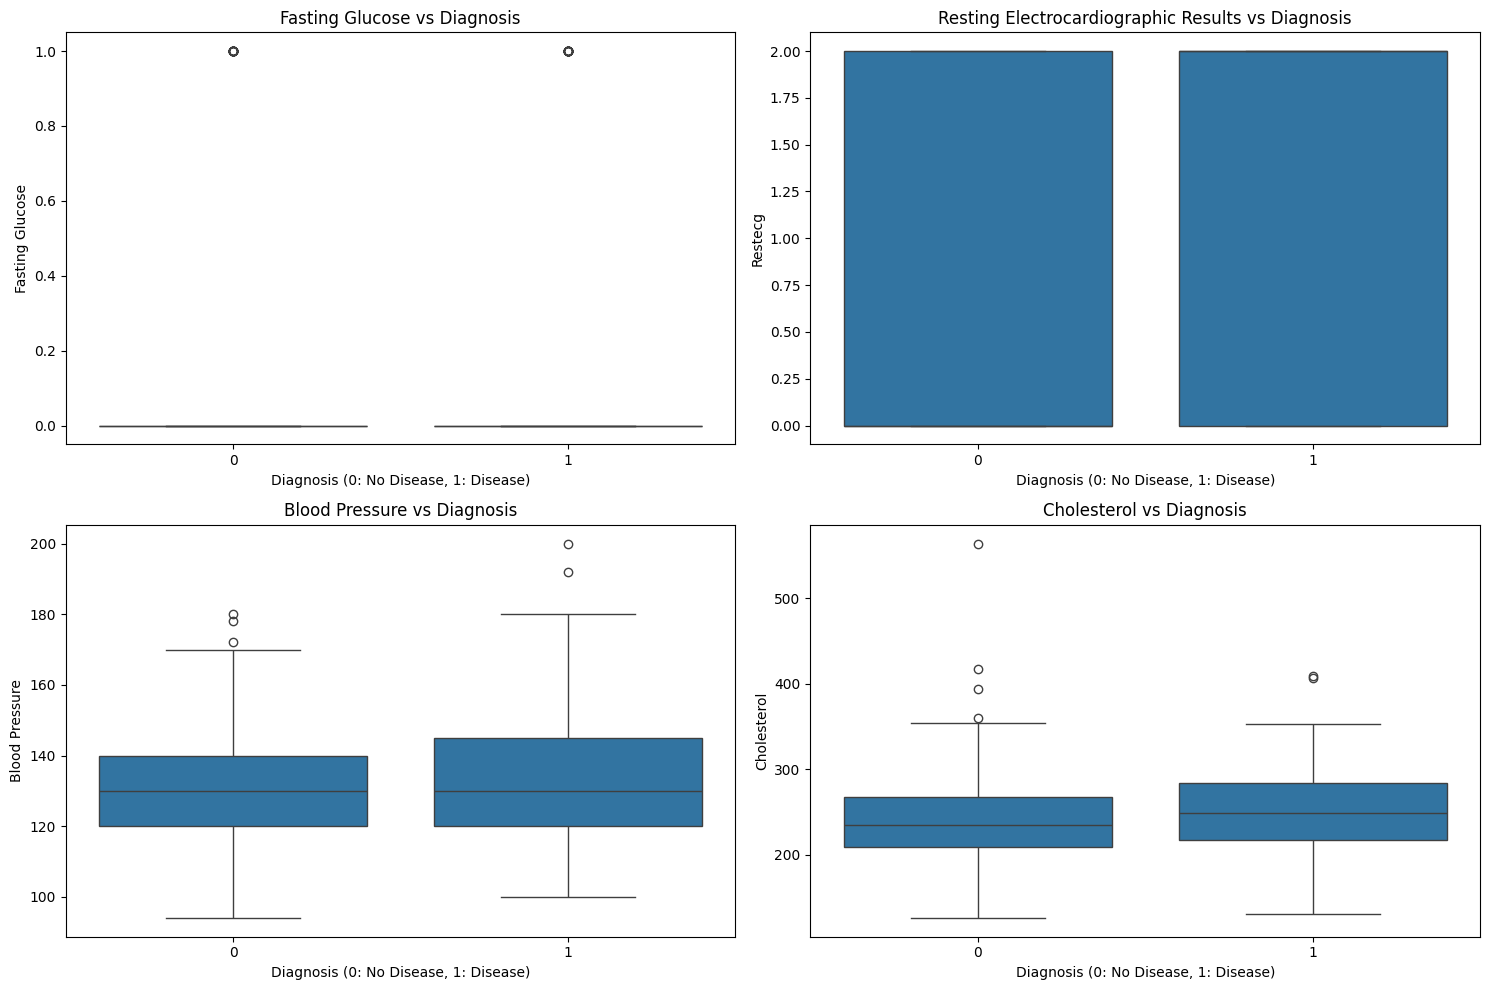

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with subplots for each feature
plt.figure(figsize=(15, 10))

# Box plot for fasting_glucose vs diagnosis
plt.subplot(2, 2, 1) # 2 rows, 2 columns, 1st plot
sns.boxplot(x=y, y=X['fasting_glucose'])
plt.title('Fasting Glucose vs Diagnosis')
plt.xlabel('Diagnosis (0: No Disease, 1: Disease)')
plt.ylabel('Fasting Glucose')

# Box plot for restecg vs diagnosis
plt.subplot(2, 2, 2) # 2 rows, 2 columns, 2nd plot
sns.boxplot(x=y, y=X['restecg'])
plt.title('Resting Electrocardiographic Results vs Diagnosis')
plt.xlabel('Diagnosis (0: No Disease, 1: Disease)')
plt.ylabel('Restecg')

# Box plot for blood_pressure vs diagnosis
plt.subplot(2, 2, 3) # 2 rows, 2 columns, 3rd plot
sns.boxplot(x=y, y=X['blood_pressure'])
plt.title('Blood Pressure vs Diagnosis')
plt.xlabel('Diagnosis (0: No Disease, 1: Disease)')
plt.ylabel('Blood Pressure')

# Box plot for cholesterol vs diagnosis
plt.subplot(2, 2, 4) # 2 rows, 2 columns, 4th plot
sns.boxplot(x=y, y=X['cholesterol'])
plt.title('Cholesterol vs Diagnosis')
plt.xlabel('Diagnosis (0: No Disease, 1: Disease)')
plt.ylabel('Cholesterol')

plt.tight_layout()
plt.show()

## Data Scaling:

We applied MinMaxScaler to all features (excluding diagnosis) to scale them to a range between 0 and 1. We created both df_scaled and df_norm (which were identical due to using the same scaler).
We displayed descriptive statistics and histograms of selected features before and after scaling to confirm the transformation and observe the preservation of distribution shapes.
We confirmed that Min-Max scaling preserves the correlation coefficients between features.

=> Estadísticas descriptivas de los datos reescalados:
              age         sex  chest_pain  blood_pressure  cholesterol  \
count  303.000000  303.000000  303.000000      303.000000   303.000000   
mean     0.529978    0.679868    0.719472        0.355564     0.275555   
std      0.188305    0.467299    0.320042        0.166035     0.118212   
min      0.000000    0.000000    0.000000        0.000000     0.000000   
25%      0.395833    0.000000    0.666667        0.245283     0.194064   
50%      0.562500    1.000000    0.666667        0.339623     0.262557   
75%      0.666667    1.000000    1.000000        0.433962     0.340183   
max      1.000000    1.000000    1.000000        1.000000     1.000000   

       fasting_glucose     restecg  max_heart_rate       exang     oldpeak  \
count       303.000000  303.000000      303.000000  303.000000  303.000000   
mean          0.148515    0.495050        0.600055    0.326733    0.167678   
std           0.356198    0.497486        0.

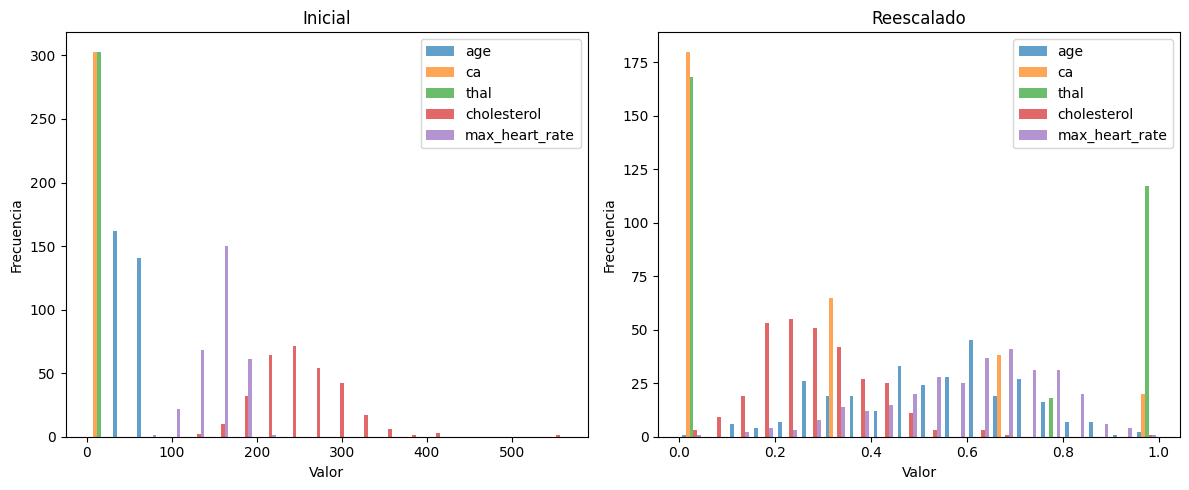

In [86]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Inicializar el objeto MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

# Seleccionar todas las columnas excepto la columna 'diagnosis' para reescalar
columnas_to_scale = df.drop(columns=['diagnosis']).columns

# Reescalar los datos
df_scaled = df.copy()
df_scaled[columnas_to_scale] = scaler.fit_transform(df[columnas_to_scale])

# Verificar los datos reescalados
print("=> Estadísticas descriptivas de los datos reescalados:")
print(df_scaled[columnas_to_scale].describe())

# Visualizar los histogramas de los datos inicial y reescalado para algunas columnas representativas
# Selecting a few columns for visualization as plotting all 13 might be too crowded
selected_for_viz = ['age', 'ca','thal', 'cholesterol', 'max_heart_rate']

fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # Changed from 1,3 to 1,2 as df_norm is removed
for i, (df_temp, title) in enumerate([(df[selected_for_viz], 'Inicial'), (df_scaled[selected_for_viz], 'Reescalado')]):
    ax = axes[i]
    ax.hist(df_temp.values, bins=20, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.legend(selected_for_viz)
plt.tight_layout()
plt.show()

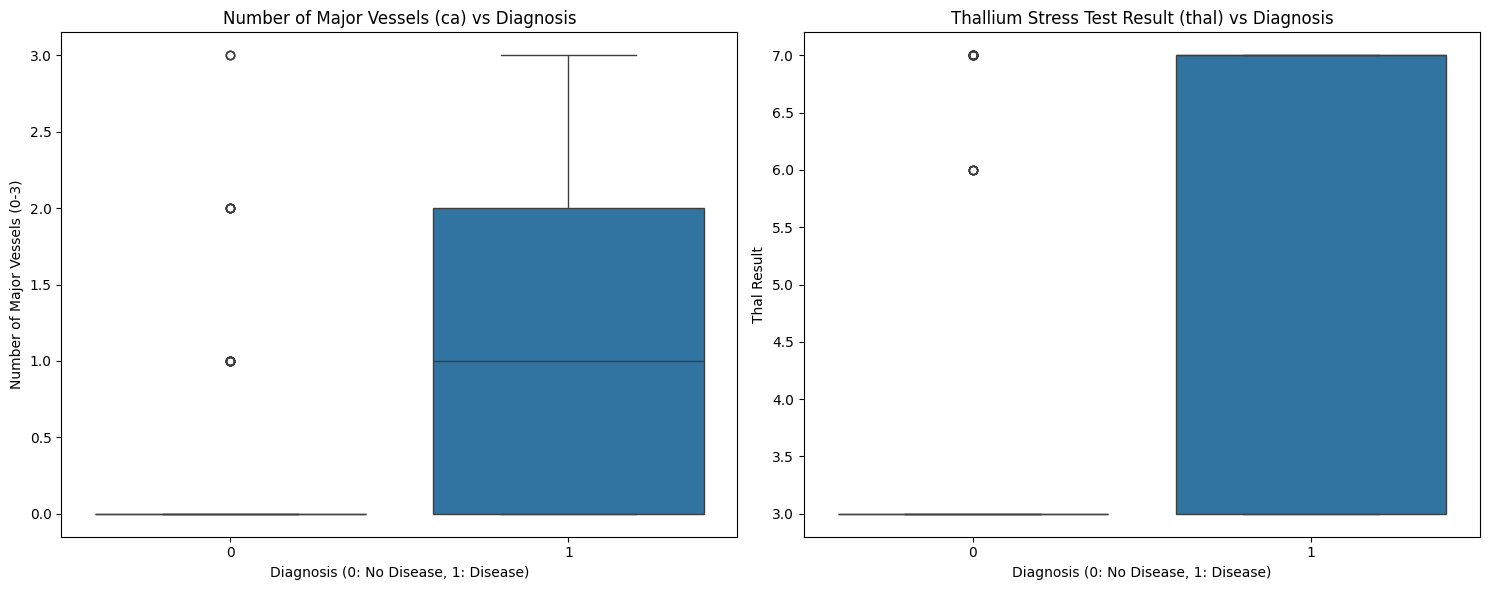

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

# Box plot for 'ca' vs diagnosis
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.boxplot(x=y, y=df['ca'])
plt.title('Number of Major Vessels (ca) vs Diagnosis')
plt.xlabel('Diagnosis (0: No Disease, 1: Disease)')
plt.ylabel('Number of Major Vessels (0-3)')

# Box plot for 'thal' vs diagnosis
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.boxplot(x=y, y=df['thal'])
plt.title('Thallium Stress Test Result (thal) vs Diagnosis')
plt.xlabel('Diagnosis (0: No Disease, 1: Disease)')
plt.ylabel('Thal Result')

plt.tight_layout()
plt.show()

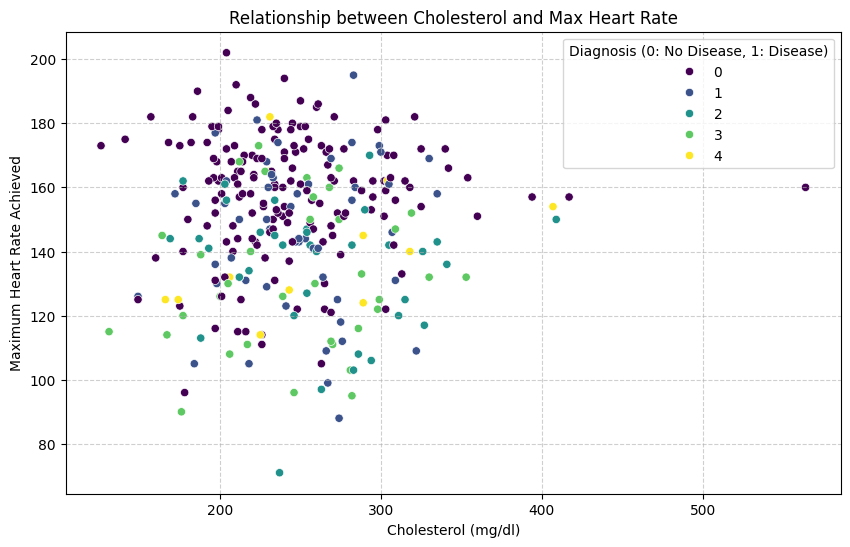

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='cholesterol', y='max_heart_rate', data=df, hue='diagnosis', palette='viridis')
plt.title('Relationship between Cholesterol and Max Heart Rate')
plt.xlabel('Cholesterol (mg/dl)')
plt.ylabel('Maximum Heart Rate Achieved')
plt.legend(title='Diagnosis (0: No Disease, 1: Disease)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Correlation Matrix Before Scaling

In [71]:
display(correlation_matrix)

,age,sex,chest_pain,blood_pressure,cholesterol,fasting_glucose,restecg,max_heart_rate,exang,oldpeak,slope,ca,thal,diagnosis
age,1.000000,-0.097542,0.104139,0.284946,0.208950,0.118530,0.148868,-0.393806,0.091661,0.203805,0.161770,0.365323,0.128303,0.222853
sex,-0.097542,1.000000,0.010084,-0.064456,-0.199915,0.047862,0.021647,-0.048663,0.146201,0.102173,0.037533,0.086048,0.380581,0.224469
chest_pain,0.104139,0.010084,1.000000,-0.036077,0.072319,-0.039975,0.067505,-0.334422,0.384060,0.202277,0.152050,0.233117,0.262089,0.407075
blood_pressure,0.284946,-0.064456,-0.036077,1.000000,0.130120,0.175340,0.146560,-0.045351,0.064762,0.189171,0.117382,0.097528,0.134424,0.157754
cholesterol,0.208950,-0.199915,0.072319,0.130120,1.000000,0.009841,0.171043,-0.003432,0.061310,0.046564,-0.004062,0.123726,0.018351,0.070909
fasting_glucose,0.118530,0.047862,-0.039975,0.175340,0.009841,1.000000,0.069564,-0.007854,0.025665,0.005747,0.059894,0.140764,0.064625,0.059186
restecg,0.148868,0.021647,0.067505,0.146560,0.171043,0.069564,1.000000,-0.083389,0.084867,0.114133,0.133946,0.131749,0.024325,0.183696
max_heart_rate,-0.393806,-0.048663,-0.334422,-0.045351,-0.003432,-0.007854,-0.083389,1.000000,-0.378103,-0.343085,-0.385601,-0.265699,-0.274142,-0.415040
exang,0.091661,0.146201,0.384060,0.064762,0.061310,0.025665,0.084867,-0.378103,1.000000,0.288223,0.257748,0.145788,0.325240,0.397057
oldpeak,0.203805,0.102173,0.202277,0.189171,0.046564,0.005747,0.114133,-0.343085,0.288223,1.000000,0.577537,0.301067,0.342405,0.504092


### Correlation Matrix After Scaling (with diagnosis column added for comparison)

Upon examining both the `correlation_matrix` (before scaling) and `correlation_scaled` (after Min-Max scaling), a crucial observation is that **the correlation values between features remain unchanged after applying `MinMaxScaler`**.

*   **Correlation is a measure of the linear relationship between two variables, and scaling (like Min-Max scaling) only transforms the data by shifting and scaling it. It does not alter the relative positions of the data points, nor the shape of their distribution, which means the linear relationships (and thus the correlation coefficients) are preserved.**

*   You can see this by comparing any specific correlation value (e.g., `age` with `blood_pressure`) in the first output (`correlation_matrix`) with the corresponding value in the second output (`correlation_scaled`). They are identical.

This is an important characteristic of many linear scaling methods. While scaling is essential for algorithms sensitive to feature magnitudes (like k-Nearest Neighbors, SVMs, or neural networks), it does not change the inherent linear dependencies between variables. Therefore, correlation analysis can often be done before or after such scaling, yielding the same results for the correlation coefficients themselves.

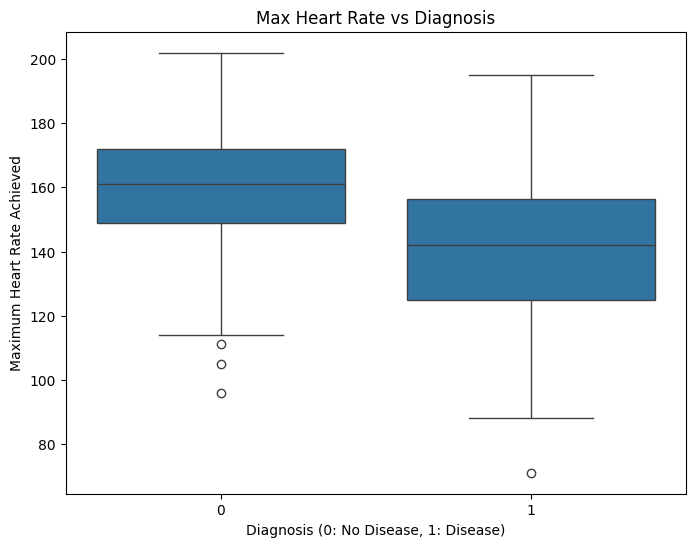

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x=y, y=X['max_heart_rate'])
plt.title('Max Heart Rate vs Diagnosis')
plt.xlabel('Diagnosis (0: No Disease, 1: Disease)')
plt.ylabel('Maximum Heart Rate Achieved')
plt.show()

## 7. Feature Selection Discussion:

We had a detailed discussion on feature selection, covering filter, wrapper, and embedded methods, and how these techniques could be applied to our dataset.

Feature selection is a crucial step in preparing your data for machine learning. It involves choosing the most relevant features (input variables) from your dataset to train your model. This process offers several benefits:

Reduces Overfitting: By removing irrelevant or redundant features, the model becomes less complex and is less likely to learn noise in the training data, leading to better generalization on unseen data.
Improves Accuracy: Sometimes, removing noisy or less predictive features can actually improve the model's predictive performance.
Reduces Training Time: Fewer features mean less data to process, resulting in faster model training and prediction.
Enhances Model Interpretability: A simpler model with fewer features is often easier to understand and explain.
There are several categories of feature selection methods:

1. Filter Methods
These methods select features based on statistical measures. They assess the relationship between each feature and the target variable independently of the machine learning model. Examples include:

Correlation Coefficient: Measures the linear relationship between two variables. We've already used this to identify features like ca, thal, oldpeak, chest_pain, and max_heart_rate as strongly correlated with diagnosis.
Chi-Squared Test: Used for categorical features to determine if there's a significant relationship with the target variable.
ANOVA (Analysis of Variance): For numerical features and a categorical target, it checks if the means of the groups are significantly different.
Mutual Information: Measures the dependency between two variables.

2. Wrapper Methods
These methods use a specific machine learning algorithm to evaluate subsets of features. They train a model on different feature subsets and select the subset that yields the best performance (e.g., highest accuracy or lowest error).

Forward Selection: Starts with no features and iteratively adds the feature that improves the model the most.
Backward Elimination: Starts with all features and iteratively removes the least useful feature.
Recursive Feature Elimination (RFE): Recursively trains the model and removes the least important features until the desired number of features is reached.

3. Embedded Methods
These methods perform feature selection as part of the model training process itself. They are specific to certain machine learning algorithms.

Lasso Regression (L1 regularization): Penalizes the absolute size of regression coefficients, effectively shrinking some coefficients to zero and thus performing feature selection.
Ridge Regression (L2 regularization): Penalizes the squared size of coefficients, which helps reduce multicollinearity but typically doesn't drive coefficients to zero.
Tree-based methods (e.g., Random Forest, Gradient Boosting): These algorithms can inherently rank features by their importance (e.g., how much they contribute to reducing impurity or error).
How to choose for our model?
Based on our initial exploratory data analysis, here's a good approach:

Leverage Correlation Analysis: We've already identified features with high and low correlation to diagnosis. Features with higher absolute correlation values (e.g., ca, thal, oldpeak, chest_pain, max_heart_rate) are good candidates to keep.
Consider Domain Knowledge: While fasting_glucose, restecg, blood_pressure, and cholesterol showed weaker correlations in our initial analysis, medical knowledge suggests they are important indicators of heart health. We should be cautious about discarding them solely based on low correlation, especially if using a model that can handle them.
Experiment with Models: Different models respond differently to feature sets. For example, linear models might benefit more from removing highly correlated features than tree-based models.
Use a Combination of Methods: A common strategy is to start with filter methods to quickly reduce the feature space, then apply wrapper or embedded methods for fine-tuning.
For our current task, given the relatively small number of features, we might start by including all of them or focusing on the ones with stronger correlations and then observe model performance. If performance is not optimal or we need more interpretability, we can then systematically apply filter or embedded methods to refine our feature set.

## 8. Data Splitting: Training and Test Sets

Before training any machine learning model, it's essential to split our dataset into training and testing sets. This allows us to train the model on one portion of the data and evaluate its performance on unseen data, preventing overfitting. We will use `train_test_split` from `sklearn.model_selection` for this purpose, using the scaled features from `df_scaled`.

In [76]:
from sklearn.model_selection import train_test_split

# Create X (features) from the scaled DataFrame, excluding the 'diagnosis' column
X_scaled = df_scaled.drop(columns=['diagnosis'])

# Split the data into training and testing sets
# test_size=0.20 means 20% of the data will be used for testing
# random_state=42 ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (242, 13)
Shape of X_test: (61, 13)
Shape of y_train: (242,)
Shape of y_test: (61,)


## Model Training and Evaluation: Logistic Regression

We will now train a Logistic Regression model, which is a common choice for binary classification tasks. After training, we will evaluate its performance using key metrics such as accuracy, precision, recall, and F1-score, and visualize the results with a confusion matrix.

Logistic Regression Model Performance:
Accuracy: 0.8852
Precision: 0.8788
Recall: 0.9062
F1-Score: 0.8923

Confusion Matrix:
[[25  4]
 [ 3 29]]


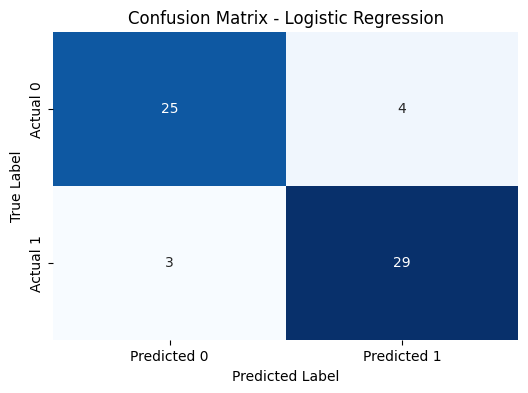


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61


Cross-Validation Accuracy for Logistic Regression (Untuned): 0.8316393442622951


In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score # Added for cross-validation

# Initialize and train the Logistic Regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# Make predictions on the test set
y_pred = log_reg.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)

# Visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Perform Cross-Validation for the untuned model
scores = cross_val_score(log_reg, X_scaled, y, cv=5) # Using X_scaled and y for CV
print("\nCross-Validation Accuracy for Logistic Regression (Untuned):", scores.mean())


## Model Training and Evaluation: Logistic Regression with L1 Regularization (Lasso)

Lasso regression, which uses L1 regularization, can also be applied to Logistic Regression. This method not only helps prevent overfitting but also performs feature selection by shrinking the coefficients of less important features to zero. We'll train and evaluate this model.

Logistic Regression with L1 Regularization Model Performance:
Accuracy: 0.8852
Precision: 0.8788
Recall: 0.9062
F1-Score: 0.8923

Confusion Matrix:
[[25  4]
 [ 3 29]]


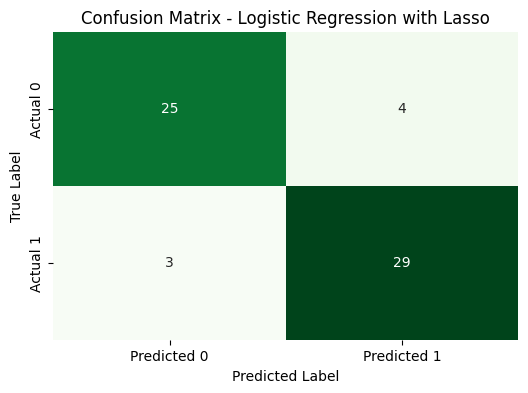


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61


Coefficients from Lasso Logistic Regression:
            Feature  Coefficient
12             thal     0.754948
11               ca     0.457566
8             exang     0.375840
1               sex     0.000000
0               age     0.000000
4       cholesterol     0.000000
3    blood_pressure     0.000000
2        chest_pain     0.000000
5   fasting_glucose     0.000000
10            slope     0.000000
6           restecg     0.000000
9           oldpeak     0.000000
7    max_heart_rate    -1.011534


In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train the Logistic Regression model with L1 regularization (solver='liblinear' supports L1)
# The 'C' parameter controls the inverse of regularization strength; smaller values mean stronger regularization.
log_reg_lasso = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, C=0.1) # C=0.1 for stronger regularization
log_reg_lasso.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lasso = log_reg_lasso.predict(X_test)

# Evaluate the model
accuracy_lasso = accuracy_score(y_test, y_pred_lasso)
precision_lasso = precision_score(y_test, y_pred_lasso)
recall_lasso = recall_score(y_test, y_pred_lasso)
f1_lasso = f1_score(y_test, y_pred_lasso)
cm_lasso = confusion_matrix(y_test, y_pred_lasso)

print(f"Logistic Regression with L1 Regularization Model Performance:")
print(f"Accuracy: {accuracy_lasso:.4f}")
print(f"Precision: {precision_lasso:.4f}")
print(f"Recall: {recall_lasso:.4f}")
print(f"F1-Score: {f1_lasso:.4f}")
print("\nConfusion Matrix:")
print(cm_lasso)

# Visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lasso, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Logistic Regression with Lasso')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lasso))

# Display coefficients to see which features were shrunk to zero (or close to zero)
print("\nCoefficients from Lasso Logistic Regression:")
lasso_coefficients = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': log_reg_lasso.coef_[0]})
print(lasso_coefficients.sort_values(by='Coefficient', ascending=False))

## Model Training with Features Selected by Lasso

Having identified the most influential features through Lasso Regression's L1 regularization, we will now train a Logistic Regression model using only these selected features. This step demonstrates how feature selection can simplify the model while aiming to preserve or enhance predictive power.

Features selected by Lasso: ['max_heart_rate', 'exang', 'ca', 'thal']

Logistic Regression Model Performance with Selected Features:
Accuracy: 0.8852
Precision: 0.9310
Recall: 0.8438
F1-Score: 0.8852

Confusion Matrix:
[[27  2]
 [ 5 27]]


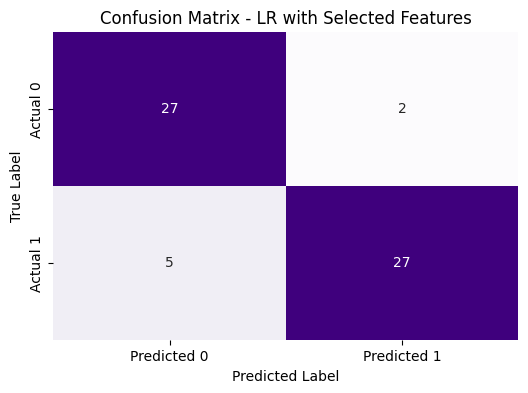


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.93      0.89        29
           1       0.93      0.84      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



In [79]:
# Get the features selected by Lasso (non-zero coefficients)
selected_features = lasso_coefficients[lasso_coefficients['Coefficient'].abs() > 0]['Feature'].tolist()

print(f"Features selected by Lasso: {selected_features}")

# Create new training and testing sets with only the selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Initialize and train a new Logistic Regression model with selected features
log_reg_selected = LogisticRegression(random_state=42)
log_reg_selected.fit(X_train_selected, y_train)

# Make predictions on the test set with selected features
y_pred_selected = log_reg_selected.predict(X_test_selected)

# Evaluate the model with selected features
accuracy_selected = accuracy_score(y_test, y_pred_selected)
precision_selected = precision_score(y_test, y_pred_selected)
recall_selected = recall_score(y_test, y_pred_selected)
f1_selected = f1_score(y_test, y_pred_selected)
cm_selected = confusion_matrix(y_test, y_pred_selected)

print(f"\nLogistic Regression Model Performance with Selected Features:")
print(f"Accuracy: {accuracy_selected:.4f}")
print(f"Precision: {precision_selected:.4f}")
print(f"Recall: {recall_selected:.4f}")
print(f"F1-Score: {f1_selected:.4f}")
print("\nConfusion Matrix:")
print(cm_selected)

# Visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_selected, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - LR with Selected Features')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_selected))

In [80]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8852459016393442

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61


Confusion Matrix:
 [[25  4]
 [ 3 29]]


In [81]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_scaled, y, cv=5)
print("CV Accuracy:", scores.mean())

CV Accuracy: 0.8217486338797816


## Visualizing Relationships of Lasso-Selected Features with Diagnosis

To further understand the features selected by Lasso Regression, we will visualize their relationship with the binary `diagnosis` target variable using box plots. This will provide insights into how these key features distribute across the two outcome classes (no disease vs. disease).

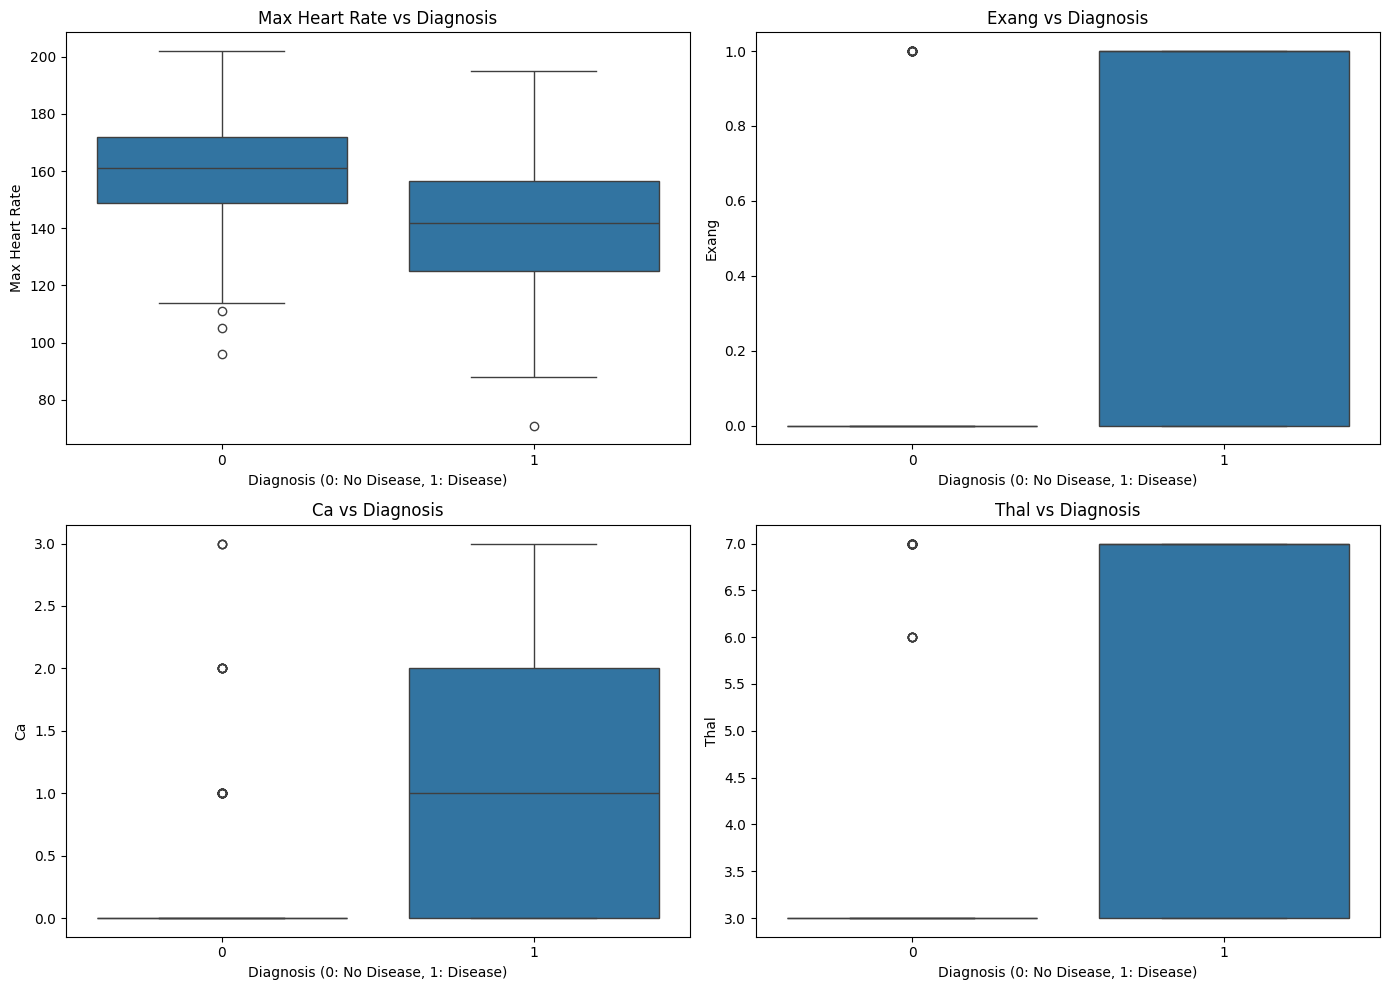

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# Features selected by Lasso Regression
selected_features = ['max_heart_rate', 'exang', 'ca', 'thal']

# Create subplots for each selected feature
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten() # Flatten the 2x2 array of axes for easier iteration

for i, feature in enumerate(selected_features):
    sns.boxplot(x=y, y=X[feature], ax=axes[i])
    axes[i].set_title(f'{feature.replace("_", " ").title()} vs Diagnosis')
    axes[i].set_xlabel('Diagnosis (0: No Disease, 1: Disease)')
    axes[i].set_ylabel(feature.replace("_", " ").title())

plt.tight_layout()
plt.show()

Visualize the relationship between each of the Lasso-selected features (max_heart_rate, exang, ca, thal) and the target variable y using box plots. This will help us understand how the distribution of these key features differs between patients with and without heart disease.

The box plots visualizing the relationship between the Lasso-selected features and the diagnosis are now displayed. Here's what we can observe:

Max Heart Rate (max_heart_rate): Patients with a diagnosis of heart disease (1) generally have a lower maximum heart rate achieved compared to those without heart disease (0). This aligns with the negative correlation we discussed earlier, suggesting that better cardiovascular fitness (higher max heart rate) is associated with a lower likelihood of disease.

Exercise-induced Angina (exang): The box plot for exang shows that patients with heart disease (1) are more likely to have exercise-induced angina (higher values for exang) than those without heart disease (0).

Number of Major Vessels colored by fluoroscopy (ca): For ca, we can see that patients with heart disease (1) tend to have a higher number of major vessels (values greater than 0, 1, 2, or 3) compared to patients without heart disease (0) who predominantly have 0 major vessels. This indicates a strong positive relationship.

Thallium Stress Test Result (thal): Similarly, for thal, individuals with heart disease (1) show different distributions, particularly higher values (e.g., 6 or 7, indicating fixed defects or reversible defects), whereas those without heart disease (0) mostly have thal values around 3 (normal). This also shows a strong association.

These visualizations confirm why Lasso Regression identified these four features as the most influential for predicting heart disease, as they clearly show distinct distributions between the two diagnosis groups.

## 10. Hyperparameter Tuning: Logistic Regression

We will now perform hyperparameter tuning for our Logistic Regression model using `GridSearchCV`. This method systematically works through multiple combinations of parameter tunes, cross-validating as it goes to determine which combination performs best on the dataset. We'll tune the regularization strength (`C`) and the type of regularization (`penalty`).

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Hyperparameters: {'C': 1, 'penalty': 'l1'}
Best Cross-validation Accuracy: 0.8305

Logistic Regression Model Performance (Tuned):
Accuracy: 0.9180
Precision: 0.9355
Recall: 0.9062
F1-Score: 0.9206

Confusion Matrix (Tuned):
[[27  2]
 [ 3 29]]


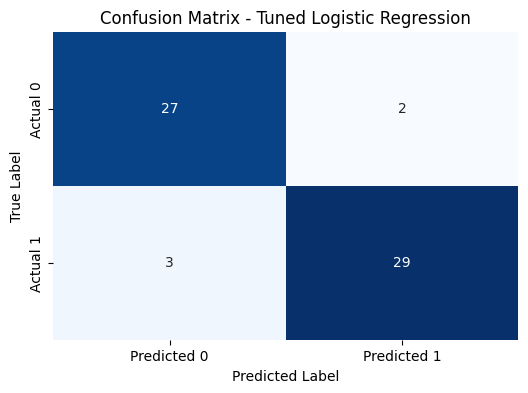


Classification Report (Tuned):
              precision    recall  f1-score   support

           0       0.90      0.93      0.92        29
           1       0.94      0.91      0.92        32

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



In [83]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the parameter grid to search
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'penalty': ['l1', 'l2']              # Specify the norm of the penalty
}

# Initialize Logistic Regression model
# 'liblinear' solver supports both 'l1' and 'l2' penalties
logistic_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)

# Initialize GridSearchCV
# cv=5 means 5-fold cross-validation
# scoring='accuracy' means the best model will be chosen based on accuracy
grid_search = GridSearchCV(logistic_model, param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best hyperparameters and corresponding score
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-validation Accuracy: {grid_search.best_score_:.4f}")

# Get the best model from the grid search
best_logistic_model = grid_search.best_estimator_

# Evaluate the best model on the test set
y_pred_tuned = best_logistic_model.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print(f"\nLogistic Regression Model Performance (Tuned):")
print(f"Accuracy: {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall: {recall_tuned:.4f}")
print(f"F1-Score: {f1_tuned:.4f}")
print("\nConfusion Matrix (Tuned):")
print(cm_tuned)

# Visualize the confusion matrix for the tuned model
plt.figure(figsize=(6, 4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Tuned Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nClassification Report (Tuned):")
print(classification_report(y_test, y_pred_tuned))

Here's what each part means:

Class 0 (No Disease):

-Precision (0.90): When the model predicts 'No Disease', it is correct 90% of the time. This means out of all instances predicted as 'No Disease', 90% actually were 'No Disease'.

-Recall (0.93): The model correctly identifies 93% of all actual 'No Disease' cases. This means out of all actual 'No Disease' instances, the model successfully found 93% of them.

-F1-Score (0.92): The F1-score is the harmonic mean of precision and recall. A value of 0.92 indicates a very good balance between precision and recall for the 'No Disease' class.

-Support (29): There were 29 actual instances of 'No Disease' in the test set.

Class 1 (Disease):

-Precision (0.94): When the model predicts 'Disease', it is correct 94% of the time. This means out of all instances predicted as 'Disease', 94% actually had 'Disease'.

-Recall (0.91): The model correctly identifies 91% of all actual 'Disease' cases. This means out of all actual 'Disease' instances, the model successfully found 91% of them.

-F1-Score (0.92): A value of 0.92 indicates a very good balance between precision and recall for the 'Disease' class.

-Support (32): There were 32 actual instances of 'Disease' in the test set.

-Accuracy (0.92): Overall, the model correctly predicted the outcome (either 'No Disease' or 'Disease') for 92% of the instances in the test set.

-Macro Avg (0.92 for precision, recall, and f1-score): This calculates the average of each metric (precision, recall, f1-score) independently for each class and then takes the average. It treats all classes equally, regardless of their support.

-Weighted Avg (0.92 for precision, recall, and f1-score): This calculates the average of each metric, weighted by the number of true instances for each class (support). Since the support for both classes is quite similar (29 vs 32), the weighted average is very close to the macro average.

In summary, the tuned model performs exceptionally well across all metrics for both classes, indicating a robust and balanced performance in predicting cardiovascular disease.

Since we are noticing a few false negatives being overlooked, lets try a ajust the weights.

--- Evaluation with custom threshold (0.3) and balanced class weights ---

Confusion Matrix (Threshold 0.3):
[[23  6]
 [ 1 31]]

Classification Report (Threshold 0.3):
              precision    recall  f1-score   support

           0       0.96      0.79      0.87        29
           1       0.84      0.97      0.90        32

    accuracy                           0.89        61
   macro avg       0.90      0.88      0.88        61
weighted avg       0.90      0.89      0.88        61


--- Evaluation with default threshold (0.5) and balanced class weights ---

Confusion Matrix (Default Threshold 0.5):
[[25  4]
 [ 3 29]]

Classification Report (Default Threshold 0.5):
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89    

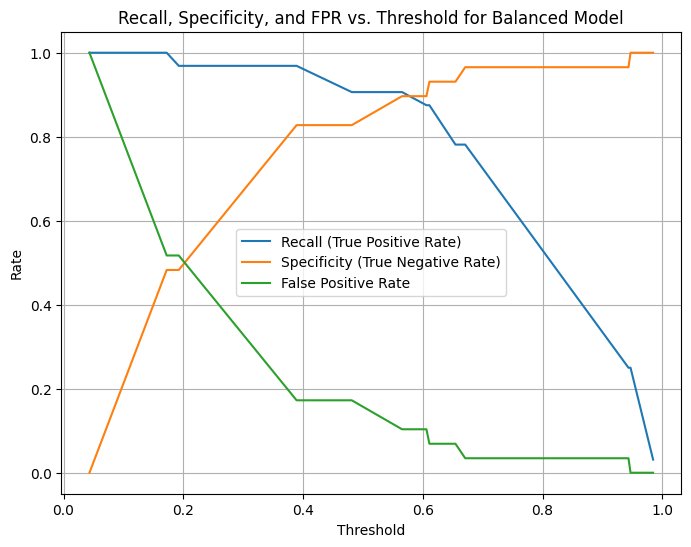

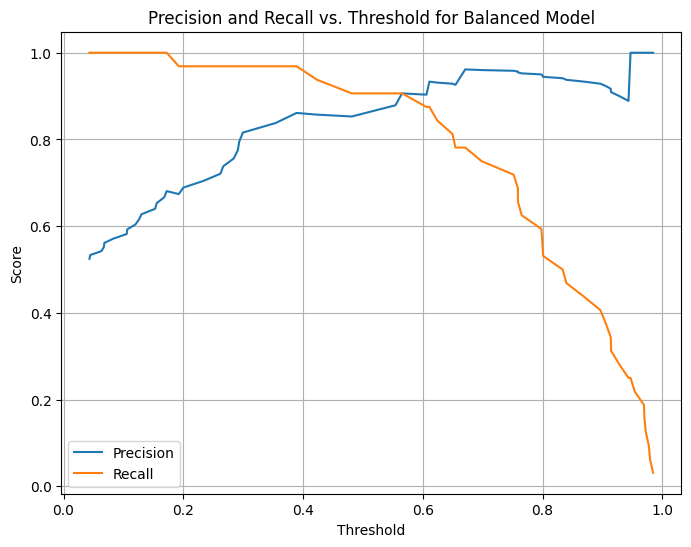

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, precision_recall_curve

# Initialize and train a new Logistic Regression model with 'balanced' class weights
# This addresses the user's comment about adjusting weights due to false negatives.
# Set random_state for reproducibility.
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Calculate probabilities from this newly trained and fitted model
y_probs = model.predict_proba(X_test)[:,1]

# Adjust the threshold (ej: 0.3) for the balanced model
y_pred_new = (y_probs > 0.3).astype(int)

print("--- Evaluation with custom threshold (0.3) and balanced class weights ---")
print("\nConfusion Matrix (Threshold 0.3):")
print(confusion_matrix(y_test, y_pred_new))
print("\nClassification Report (Threshold 0.3):")
print(classification_report(y_test, y_pred_new))

# For comparison, evaluate with default threshold (0.5) from the balanced model
y_pred_balanced = model.predict(X_test)
print("\n--- Evaluation with default threshold (0.5) and balanced class weights ---")
print("\nConfusion Matrix (Default Threshold 0.5):")
print(confusion_matrix(y_test, y_pred_balanced))
print("\nClassification Report (Default Threshold 0.5):")
print(classification_report(y_test, y_pred_balanced))


# Plot ROC curve related metrics for understanding threshold impact
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, tpr, label="Recall (True Positive Rate)")
plt.plot(thresholds, 1 - fpr, label="Specificity (True Negative Rate)") # 1-FPR is Specificity
plt.plot(thresholds, fpr, label="False Positive Rate")
plt.legend()
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("Recall, Specificity, and FPR vs. Threshold for Balanced Model")
plt.grid(True)
plt.show()

# Plot precision and recall vs threshold
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(pr_thresholds, precision[:-1], label="Precision")
plt.plot(pr_thresholds, recall[:-1], label="Recall")
plt.legend()
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs. Threshold for Balanced Model")
plt.grid(True)
plt.show()

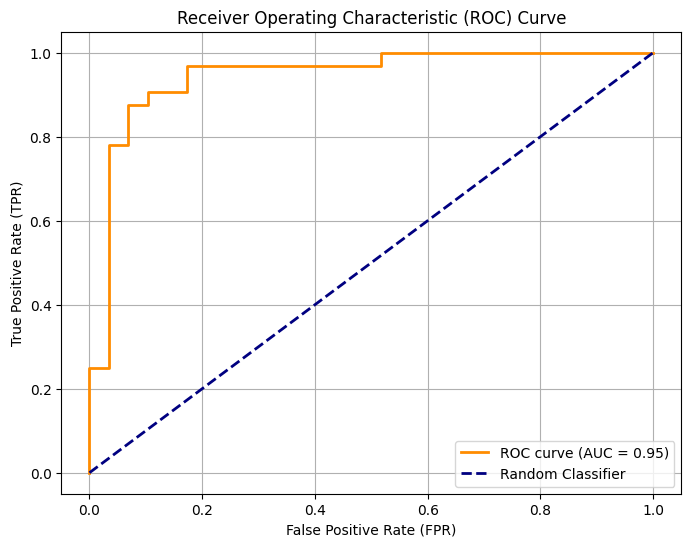

In [88]:
from sklearn.metrics import roc_auc_score

# Calculate AUC
auc_score = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()